# 1. Necessary Imports

In [31]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


start_date = "2019-01-01"
end_date = "2024-01-01"

#functions


#data
data = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)

from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)


#checking data
print(rfr)
print(data.head())

[*********************100%***********************]  1 of 1 completed

0.022721041324881567
                 AAPL        BND        EEM         GLD        JPM  \
Date                                                                 
2019-01-02  37.503719  64.321144  33.319092  121.330002  81.250198   
2019-01-03  33.768074  64.572395  32.715000  122.430000  80.095520   
2019-01-04  35.209610  64.377899  33.770039  121.440002  83.048256   
2019-01-07  35.131237  64.280640  33.846611  121.860001  83.105988   
2019-01-08  35.800953  64.199623  33.974239  121.529999  82.949272   

                   SPY        TSM        XOM  
Date                                          
2019-01-02  224.995331  31.237247  50.001846  
2019-01-03  219.626312  29.389698  49.234127  
2019-01-04  226.982849  29.911461  51.049377  
2019-01-07  228.772491  30.133848  51.314842  
2019-01-08  230.921951  29.885792  51.687950  


# 2. Basic Plotting

## 2.1. Asset Price Path

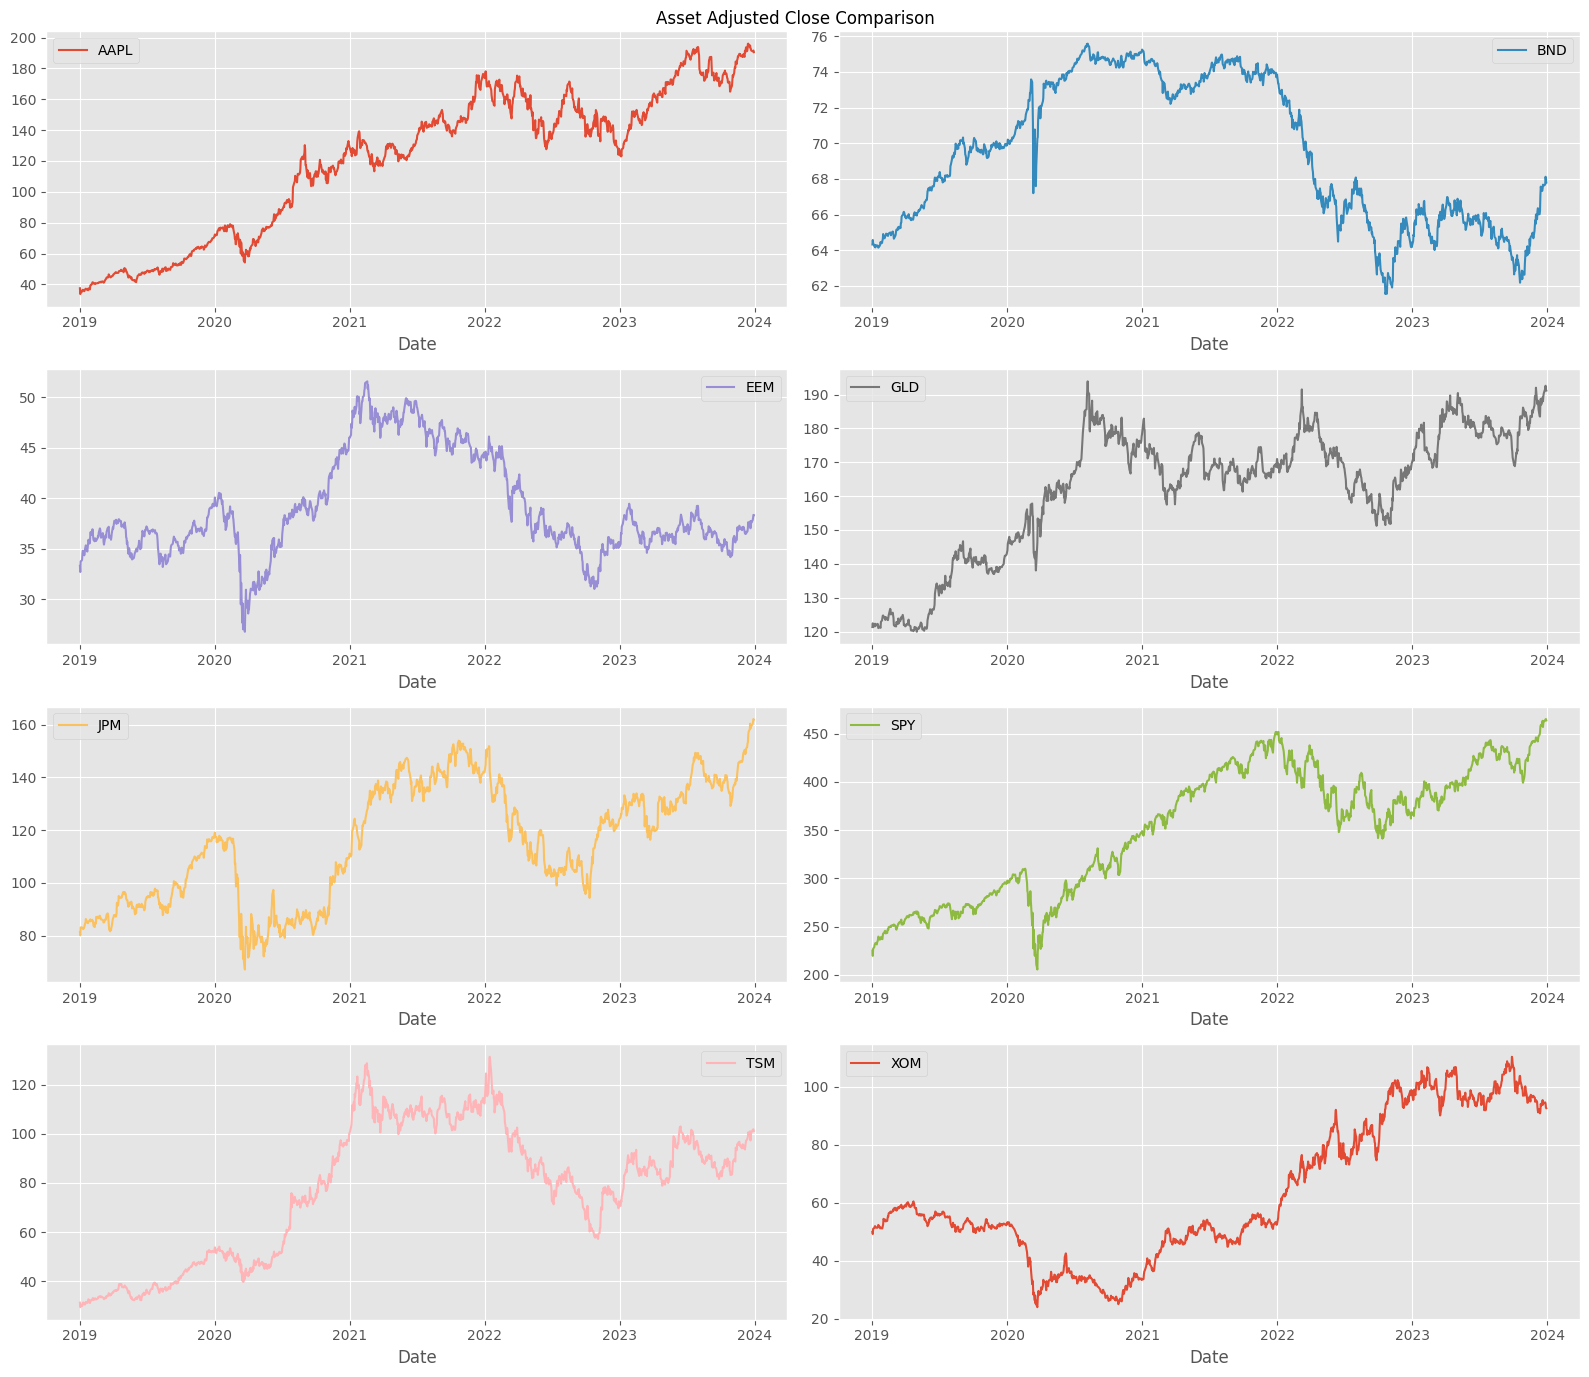

In [32]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

axes = data.plot(
    subplots=True, 
    layout=(4, 2),       
    figsize=(16, 14),  
    sharex=False,    
    grid=True,             
    linewidth=1.5,
    title="Asset Adjusted Close Comparison",
)
plt.tight_layout()      


## 2.2. Volatility (on log returns)

In [33]:
log_returns = np.log(data/data.shift(1))
log_returns = log_returns.dropna()  #drops first row
print(log_returns.shape)
log_returns.head()

(1257, 8)


,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,-0.104924,0.003899,-0.018297,0.009025,-0.014313,-0.024152,-0.060967,-0.015473
2019-01-04,0.041803,-0.003017,0.031740,-0.008119,0.036202,0.032947,0.017598,0.036206
2019-01-07,-0.002228,-0.001512,0.002265,0.003453,0.000695,0.007854,0.007407,0.005187
2019-01-08,0.018884,-0.001261,0.003764,-0.002712,-0.001888,0.009352,-0.008266,0.007245
2019-01-09,0.016839,0.001387,0.017625,0.006398,-0.001692,0.004663,0.018995,0.005261


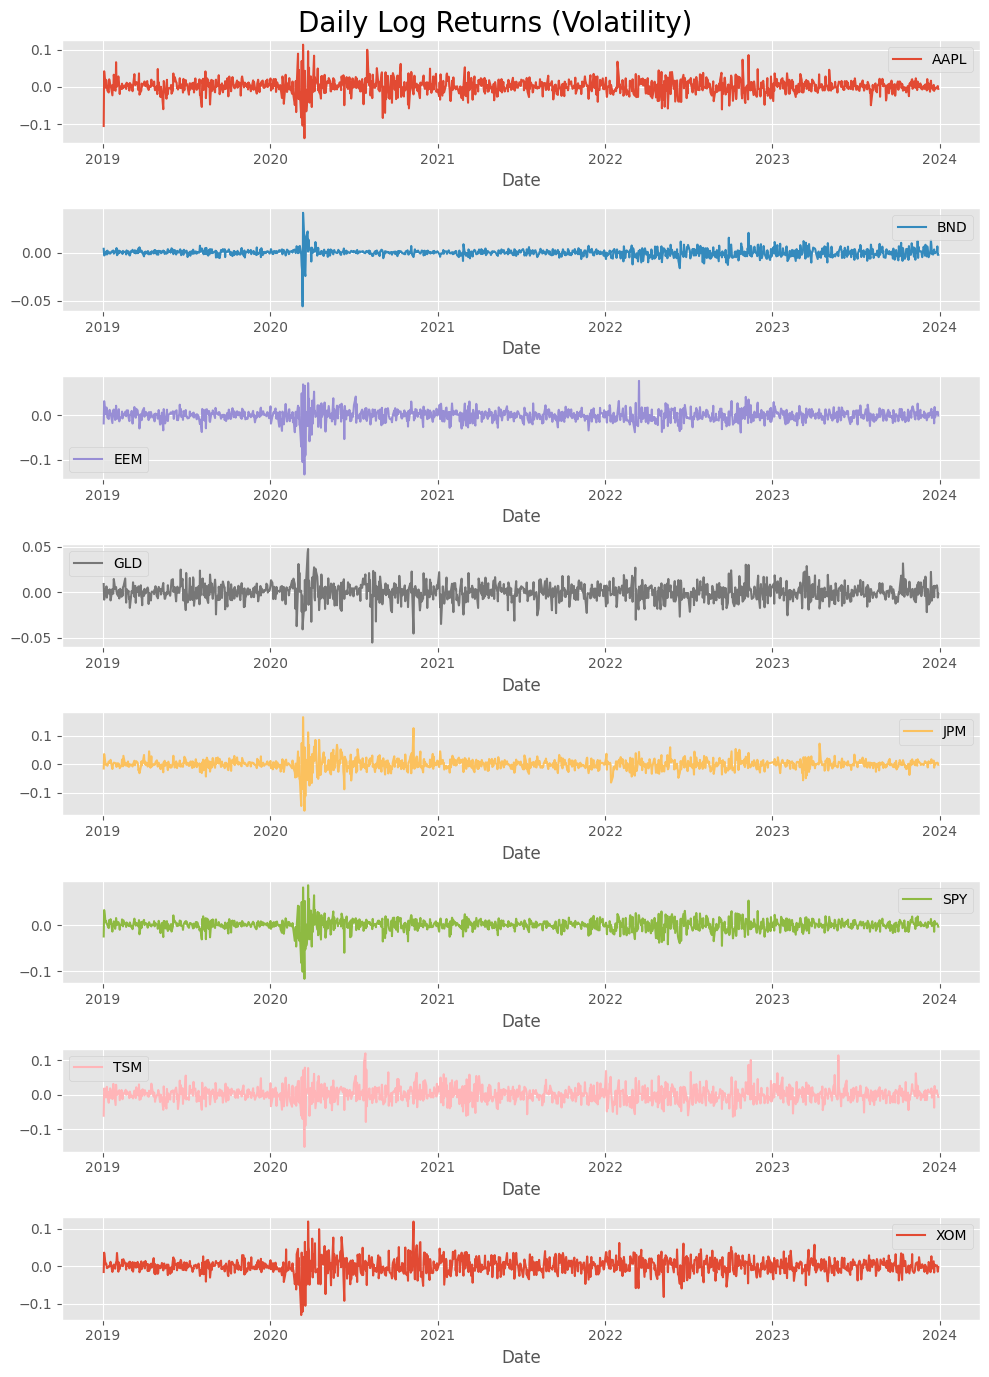

In [34]:
log_returns.plot(figsize=(10,14), subplots=True, sharex=False)
plt.suptitle('Daily Log Returns (Volatility)', fontsize=20)

plt.tight_layout()


## 2.3. Volatility Clustering

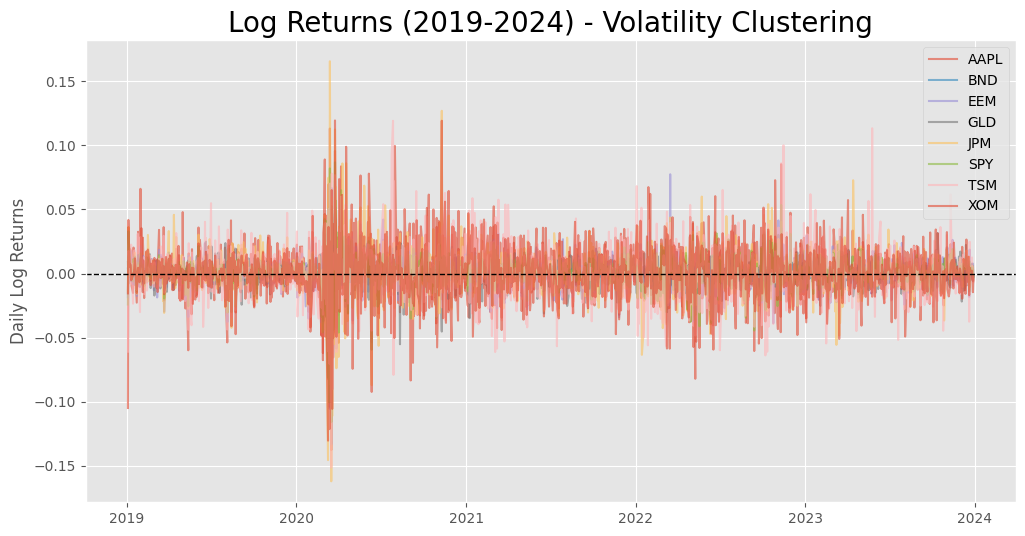

In [35]:
import matplotlib.pyplot as plt

# --- 1. Szereg czasowy (Wizualizacja Volatility Clustering) ---
# Powinieneś zauważyć, że w okresach kryzysów (np. marzec 2020) 
# wykres "szaleje" (duże odchylenia od zera) dla wszystkich aktywów naraz.
plt.figure(figsize=(12, 6))
plt.plot(log_returns, alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Log Returns (2019-2024) - Volatility Clustering', fontsize=20)
plt.ylabel('Daily Log Returns')
plt.legend(log_returns.columns)
plt.show()


In [36]:
np.exp(log_returns.std() * 252) - 1

AAPL    166.246238
BND       1.929124
EEM      34.630921
GLD       9.732609
JPM     155.693582
SPY      27.411382
TSM     280.282823
XOM     229.980925
dtype: float64

## 2.4. Daily Log Returns Distribution with Volatility ($\sigma$)

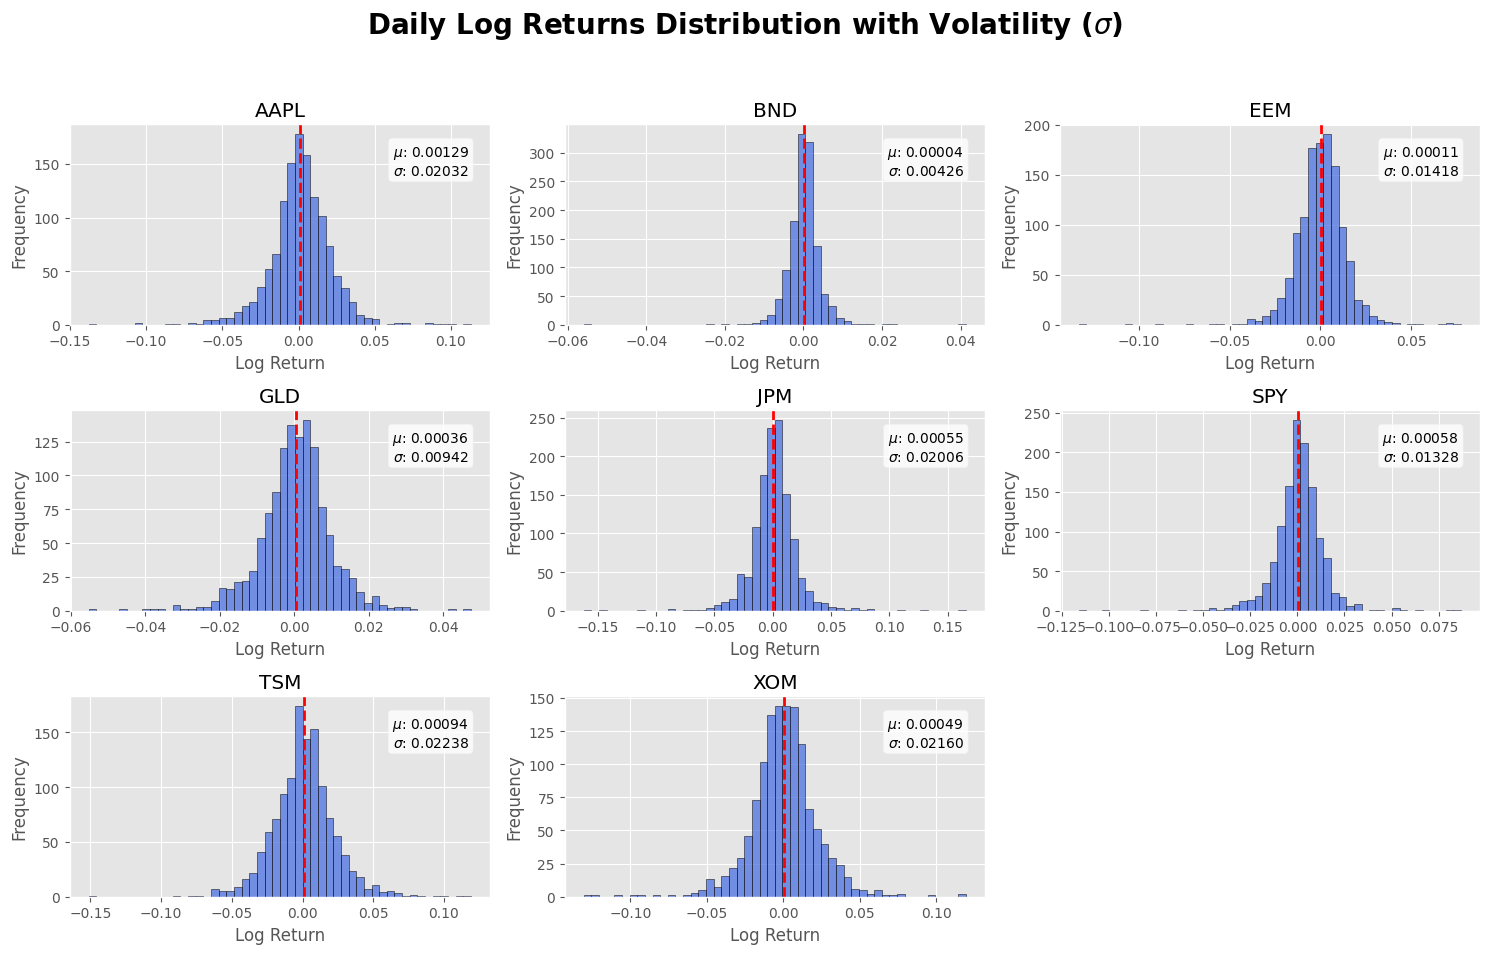

In [37]:
axes = log_returns.hist(bins=50, figsize=(15, 10), color='royalblue', 
                        edgecolor='black', alpha=0.7)

# 2. Iterate and Annotate
for ax in axes.flatten():
    ticker = ax.get_title()
    
    if ticker in log_returns.columns:
        # Calculate stats on non-null data
        data = log_returns[ticker].dropna()
        mean_val = data.mean()
        std_val = data.std()
        
        # Vertical line for the mean (Drift)
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label='Mean')
        
        # Add Text Box with μ and σ
        stats_text = rf'$\mu$: {mean_val:.5f}' + '\n' + rf'$\sigma$: {std_val:.5f}'
        ax.text(0.95, 0.90, stats_text, transform=ax.transAxes, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Log Return')
        ax.set_ylabel('Frequency')
    else:
        # Clean up empty subplots if grid is larger than number of tickers
        ax.set_axis_off()


plt.suptitle(r'Daily Log Returns Distribution with Volatility ($\sigma$)', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

## 2.5 Covariance Martix and Volatility

In [38]:
#daily
daily_covar_martix = log_returns.cov()
daily_covar_martix

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
AAPL,0.000413,0.000012,0.000178,0.000016,0.000187,0.000217,0.000260,0.000142
BND,0.000012,0.000018,0.000010,0.000015,0.000003,0.000011,0.000010,-0.000003
EEM,0.000178,0.000010,0.000201,0.000025,0.000174,0.000147,0.000219,0.000150
GLD,0.000016,0.000015,0.000025,0.000089,-0.000010,0.000013,0.000025,0.000012
JPM,0.000187,0.000003,0.000174,-0.000010,0.000402,0.000196,0.000192,0.000257
SPY,0.000217,0.000011,0.000147,0.000013,0.000196,0.000176,0.000189,0.000160
TSM,0.000260,0.000010,0.000219,0.000025,0.000192,0.000189,0.000501,0.000152
XOM,0.000142,-0.000003,0.000150,0.000012,0.000257,0.000160,0.000152,0.000466


In [39]:
#annual
trading_days = 252

annualized_covar_matrix = daily_covar_martix * 252
annualized_covar_matrix

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
AAPL,0.104004,0.003023,0.044897,0.004116,0.047067,0.054788,0.065439,0.035702
BND,0.003023,0.004583,0.002593,0.003841,0.000653,0.002653,0.002432,-0.000732
EEM,0.044897,0.002593,0.050666,0.006315,0.043811,0.036959,0.055228,0.037788
GLD,0.004116,0.003841,0.006315,0.022351,-0.002446,0.003392,0.006189,0.003077
JPM,0.047067,0.000653,0.043811,-0.002446,0.101372,0.049386,0.048264,0.064863
SPY,0.054788,0.002653,0.036959,0.003392,0.049386,0.044448,0.047560,0.040244
TSM,0.065439,0.002432,0.055228,0.006189,0.048264,0.047560,0.126200,0.038406
XOM,0.035702,-0.000732,0.037788,0.003077,0.064863,0.040244,0.038406,0.117536


In [40]:
#variances and volatilities
annual_variances = np.diag(annualized_covar_matrix)

annual_volatilities = np.sqrt(annual_variances)

volatility_series = pd.Series(annual_volatilities, index=annualized_covar_matrix.columns)

print("--- ANNUALIZED VOLATILITY ---")
print(volatility_series)

--- ANNUALIZED VOLATILITY ---
AAPL    0.322496
BND     0.067700
EEM     0.225091
GLD     0.149503
JPM     0.318390
SPY     0.210828
TSM     0.355246
XOM     0.342835
dtype: float64


## 2.6. Returns

In [41]:
# log annualized returns (average) 
log_annualized_returns_average_asset = log_returns.mean() * trading_days
log_annualized_returns_average_asset

AAPL    0.325871
BND     0.010549
EEM     0.028170
GLD     0.091147
JPM     0.138290
SPY     0.145039
TSM     0.235629
XOM     0.123630
dtype: float64

In [42]:
#converted to actual annual returns (discrete)
# This creates a new Series of formatted strings
annualized_returns_average_asset = ((np.exp(log_annualized_returns_average_asset) - 1) * 100).map("{:.2f}%".format)
annualized_returns_average_asset


AAPL    38.52%
BND      1.06%
EEM      2.86%
GLD      9.54%
JPM     14.83%
SPY     15.61%
TSM     26.57%
XOM     13.16%
dtype: str

## 2.7. Correlation

Text(0.5, 1.0, 'Correlation Matrix')

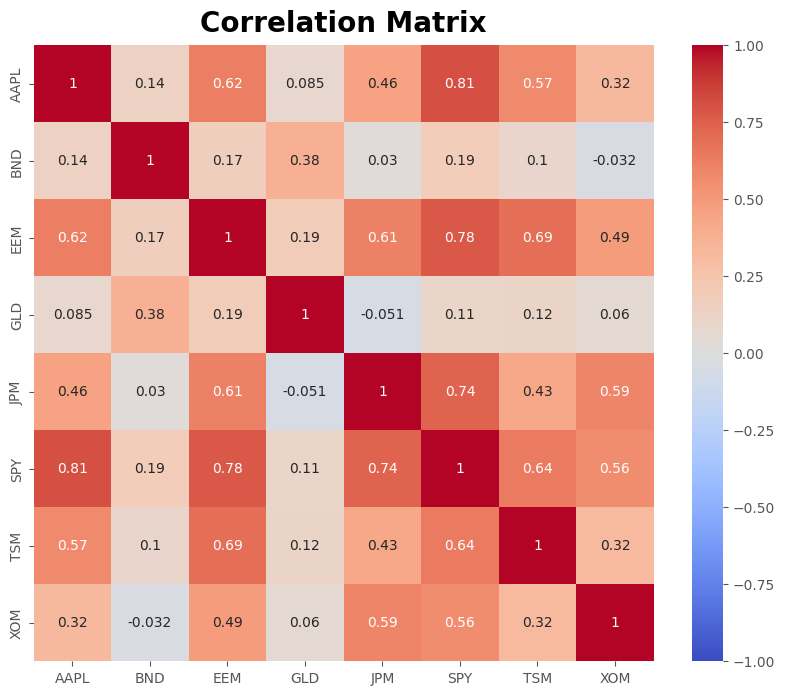

In [43]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(log_returns.corr(), annot=True, cmap='coolwarm',vmin=-1)
plt.title('Correlation Matrix', fontsize=20, pad=10, fontweight='demibold')

### Bonds and Gold are uncorrelated with most assets.